# ============================================================
# ANT COLONY OPTIMIZATION (ACO)
# ============================================================
#
# Ant Colony Optimization (ACO) es una metaheurística inspirada
# en el comportamiento de las hormigas reales cuando buscan
# alimento. Las hormigas depositan feromonas sobre los caminos
# que recorren y, con el tiempo, los caminos más cortos reciben
# una mayor cantidad de feromonas porque son recorridos con más
# frecuencia.
#
# El algoritmo simula este comportamiento construyendo múltiples
# rutas en cada iteración. Cada hormiga genera una solución
# completa para el problema TSP y, posteriormente, las mejores
# rutas refuerzan las feromonas de los caminos utilizados.
#
# A diferencia de Simulated Annealing y Tabu Search, que trabajan
# con una única solución a la vez, ACO trabaja con una población
# de soluciones generadas por varias hormigas simultáneamente.
#
# El objetivo es que la colonia aprenda progresivamente cuáles
# son las conexiones más prometedoras hasta converger hacia una
# ruta de bajo costo.
#
# ============================================================
# VARIABLES PRINCIPALES DEL ALGORITMO
# ============================================================
#
# 1) ITERACIONES = 50
#
# Corresponde a la cantidad de ciclos completos de aprendizaje
# que realizará la colonia.
#
# En cada iteración ocurre:
#
#   1. Las hormigas construyen rutas.
#   2. Se evalúa el costo de cada ruta.
#   3. Se actualizan las feromonas.
#   4. Se evaporan las feromonas antiguas.
#
# Mientras más iteraciones existan:
#
#   + Mayor aprendizaje colectivo.
#   + Mayor refinamiento de las rutas.
#   + Mayor tiempo de ejecución.
#
# Si se utilizan muy pocas iteraciones, la colonia puede no
# alcanzar a identificar las mejores rutas.
#
# Se seleccionaron 50 iteraciones porque representan un equilibrio
# adecuado entre calidad de solución y tiempo de ejecución para
# un problema de 16 ciudades.
#
#
# 2) HORMIGAS = 10
#
# Define cuántas soluciones distintas se generan en cada
# iteración.
#
# Cada hormiga construye una ruta completa desde cero.
#
# Ejemplo:
#
#   Hormiga 1 -> Ruta A
#   Hormiga 2 -> Ruta B
#   Hormiga 3 -> Ruta C
#   ...
#   Hormiga 10 -> Ruta J
#
# Más hormigas permiten explorar una mayor cantidad de soluciones
# en cada iteración.
#
# Ventajas de aumentar el valor:
#
#   + Más diversidad.
#   + Más exploración.
#   + Mayor probabilidad de encontrar rutas buenas.
#
# Desventajas:
#
#   - Mayor tiempo de ejecución.
#   - Más cálculos de feromonas.
#
# Se seleccionaron 10 hormigas porque generan suficiente
# diversidad sin aumentar excesivamente el costo computacional.
#
#
# 3) ALPHA = 1
#
# Alpha controla la influencia de las feromonas durante la toma
# de decisiones.
#
# Las feromonas representan la memoria colectiva de la colonia.
#
# Mientras más feromona tenga una conexión, más atractiva será
# para futuras hormigas.
#
# Si Alpha aumenta:
#
#   + Las hormigas siguen más los caminos conocidos.
#   + La convergencia es más rápida.
#
# Sin embargo:
#
#   - Disminuye la exploración.
#   - Puede producir convergencia prematura.
#
# Si Alpha disminuye:
#
#   + Aumenta la exploración.
#
# Pero:
#
#   - Se aprovecha menos la experiencia acumulada.
#
# Se seleccionó Alpha = 1 porque entrega un equilibrio adecuado
# entre aprendizaje y exploración.
#
#
# 4) BETA = 2
#
# Beta controla la importancia de la distancia entre ciudades.
#
# Mientras Alpha representa experiencia acumulada, Beta
# representa una decisión más "codiciosa" basada en cercanía.
#
# Si Beta aumenta:
#
#   + Las hormigas prefieren ciudades cercanas.
#   + Encuentran rápidamente rutas razonables.
#
# Sin embargo:
#
#   - Existe riesgo de caer en mínimos locales.
#
# Si Beta disminuye:
#
#   + Las decisiones son menos influenciadas por la distancia.
#
# Pero:
#
#   - La búsqueda se vuelve más aleatoria.
#
# Se seleccionó Beta = 2 porque en problemas TSP suele ser
# conveniente dar más importancia a la distancia que a la
# feromona acumulada.
#
#
# 5) EVAPORACION = 0.5
#
# Controla la pérdida de feromonas en cada iteración.
#
# Después de que las hormigas depositan nuevas feromonas,
# una parte de las existentes desaparece.
#
# Esto evita que la colonia quede atrapada para siempre en
# una decisión tomada durante las primeras iteraciones.
#
# Si la evaporación es muy baja:
#
#   + La colonia recuerda durante mucho tiempo.
#
# Pero:
#
#   - Puede estancarse rápidamente.
#
# Si la evaporación es muy alta:
#
#   + Se favorece la exploración.
#
# Pero:
#
#   - La colonia olvida demasiado rápido.
#
# Se seleccionó un valor de 0.5 porque elimina el 50% de las
# feromonas en cada iteración, manteniendo un equilibrio entre
# memoria colectiva y exploración.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math
import time

ciudades = np.array([

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)

])

n_ciudades = len(ciudades)

print("Cantidad de ciudades:", n_ciudades)

Cantidad de ciudades: 16


In [2]:
def distancia(a, b):
    return np.linalg.norm(a - b)

In [3]:
dist_matrix = np.array([
    [distancia(ciudades[i], ciudades[j]) for j in range(n_ciudades)]
    for i in range(n_ciudades)
])

In [4]:
def costo(ruta):
    return sum(dist_matrix[ruta[i]][ruta[i+1]] for i in range(len(ruta)-1)) + dist_matrix[ruta[-1]][ruta[0]]

In [5]:
def plot_ruta(ruta, titulo="Ruta"):
    r = np.array([ciudades[i] for i in ruta] + [ciudades[ruta[0]]])

    plt.figure()
    plt.plot(r[:,0], r[:,1], marker='o')
    plt.title(titulo)
    plt.show()

In [6]:
def generar_vecino(ruta):
    vecino = ruta[:]
    i, j = random.sample(range(n_ciudades), 2)
    vecino[i], vecino[j] = vecino[j], vecino[i]
    return vecino

In [7]:
def ant_colony_optimization(iteraciones=50, hormigas=10, alpha=1, beta=2, evaporacion=0.5):
    feromonas = np.ones((n_ciudades, n_ciudades))

    mejor = None

    for _ in range(iteraciones):
        rutas = []

        for _ in range(hormigas):
            actual = random.randint(0, n_ciudades - 1)
            ruta = [actual]
            no_visitadas = set(range(n_ciudades)) - set(ruta)

            while no_visitadas:
                probabilidades = []

                for j in no_visitadas:
                    tau = feromonas[actual][j] ** alpha
                    eta = (1 / dist_matrix[actual][j]) ** beta
                    probabilidades.append(tau * eta)

                probabilidades = np.array(probabilidades)
                probabilidades = probabilidades / probabilidades.sum()

                siguiente = random.choices(list(no_visitadas), probabilidades)[0]

                ruta.append(siguiente)
                no_visitadas.remove(siguiente)
                actual = siguiente

            rutas.append(ruta)

        feromonas *= (1 - evaporacion)

        for ruta in rutas:
            for i in range(n_ciudades - 1):
                feromonas[ruta[i]][ruta[i+1]] += 1.0 / costo(ruta)

        mejor = min(rutas, key=costo)

    return mejor

In [9]:
inicio = time.time()

mejor_ruta = ant_colony_optimization()

fin = time.time()

tiempo_total = fin - inicio

===== ANT COLONY OPTIMIZATION =====

Ruta encontrada:
[7, 6, 4, 5, 13, 8, 10, 9, 11, 1, 0, 2, 3, 12, 15, 14, 7]

Costo total:
266.24

Cantidad de ciudades:
16

Iteraciones:
50

Hormigas:
10

Alpha (peso de feromonas):
1

Beta (peso de distancia):
2

Evaporación:
0.5

Tiempo:
0.4324 segundos


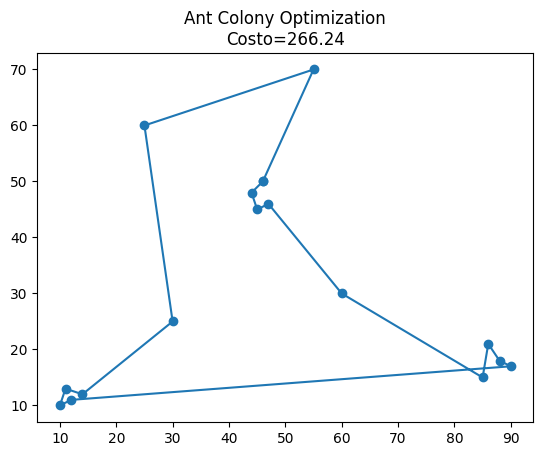

In [11]:
print("===== ANT COLONY OPTIMIZATION =====\n")

print("Ruta encontrada:")
print(mejor_ruta + [mejor_ruta[0]])

print("\nCosto total:")
print(round(costo(mejor_ruta), 2))

print("\nCantidad de ciudades:")
print(n_ciudades)

print("\nIteraciones:")
print(50)

print("\nHormigas:")
print(10)

print("\nAlpha (peso de feromonas):")
print(1)

print("\nBeta (peso de distancia):")
print(2)

print("\nEvaporación:")
print(0.5)

print("\nTiempo:")
print(round(tiempo_total, 4), "segundos")
plot_ruta(
    mejor_ruta,
    f"Ant Colony Optimization\nCosto={round(costo(mejor_ruta),2)}"
)